In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
df_1 = pd.read_csv("books.csv")
df_2 = pd.read_csv("book_tags.csv")
df_3 = pd.read_csv("ratings.csv")
print(df_2)

       goodreads_book_id  tag_id  count
0                    386   30574    565
1                    386   19733    280
2                    386   21689    182
3                    386   21773     99
4                    386   19742     78
...                  ...     ...    ...
40195           31845516   13254      7
40196           31845516   19734      7
40197           31845516     833      7
40198           31845516   23471      6
40199           31845516    9477      6

[40200 rows x 3 columns]


In [32]:
#1 Books without an original title
count = df_1['original_title'].isna().sum()
print(count)

36


In [33]:
#2 Unique books in the dataset
cleaned_books = df_1.dropna(subset=['original_title'])
book_tags_cleaned = df_2[df_2['goodreads_book_id'].isin(df_1['book_id'])]
df_3 = df_3[df_3['book_id'].isin(df_1['book_id'])]
unique_books = cleaned_books['book_id'].nunique()
print(f"Unique books: {unique_books}")

Unique books: 363


In [34]:
#3 Unique users in ratings.csv dataset
count = df_3['user_id'].nunique()
print(count)

40836


In [35]:
#4 Unique tags in book_tags.csv dataset
count = df_2['tag_id'].nunique()
print(count)

3651


In [36]:
#5 Most frequently used tag ids in book_tags.csv dataset
tags = df_2['tag_id'].value_counts()
maximum_value = tags.max()
tag_with_maximum_count = tags[tags == maximum_value].index.min()
print(tag_with_maximum_count)

4600


In [37]:
#6 book with maximum count tag
maximum_count = df_2.loc[df_2['count'].idxmax()]
goodreads_id_maximum_count = maximum_count['goodreads_book_id']
book_title = df_1.loc[df_1['goodreads_book_id'] == goodreads_id_maximum_count, 'title'].values[0]
print(book_title)

Bossypants


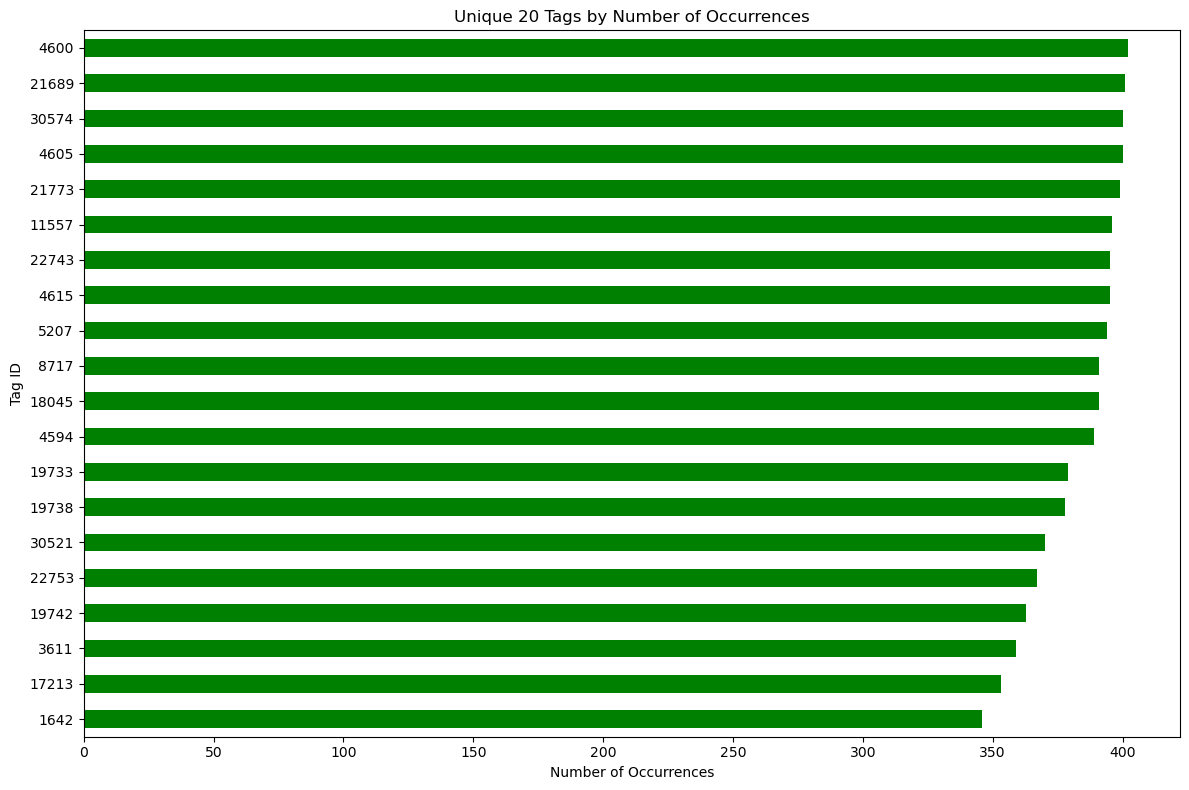

In [38]:
#7 Bar chart with 20 unique tags in descending order
counts = df_2['tag_id'].value_counts().nlargest(20)

plt.figure(figsize=(12, 8))
counts.sort_values(ascending=True).plot(kind='barh', color='green')
plt.title('Unique 20 Tags by Number of Occurrences')
plt.xlabel('Number of Occurrences')
plt.ylabel('Tag ID')
plt.tight_layout()
plt.show()